In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn import metrics

# incarcarea bazei de date
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# eliminam atributele stress_level, anxiety_level si addiction_level
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

# transformam variabile text in numerice
def encode_text(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

nume_atribute = ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 
                 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 
                 'physical_activity', 'social_interaction_level']

df = encode_text(df, ['gender', 'platform_usage', 'social_interaction_level'])

# separare X (atribute) si y (scop)
X = df[nume_atribute].values
y = df['depression_label'].values

# functie pentru rularea experimentului
def experiment_arbore(k_fold_val, criteriu, adancime, min_leaf, nume_exp):
    print(f"\n\n--- {nume_exp} (Criterion={criteriu}, MaxDepth={adancime}, MinLeaf={min_leaf}) ---")
    
    # crearea modelului arborelui de decizie
    dt = DecisionTreeClassifier(criterion=criteriu, max_depth=adancime, 
                                min_samples_leaf=min_leaf, random_state=1)
    
    kf = KFold(n_splits=k_fold_val, shuffle=True, random_state=42)
    
    # realizarea clasificarii prin k-fold
    y_pred = cross_val_predict(dt, X, y, cv=kf)

    # calcularea acuratetii modelului si afisarea acesteia
    print("Accuracy:", metrics.accuracy_score(y, y_pred))
    
    # afisare raport de clasificare
    print(classification_report(y, y_pred))

    # generare matrice de confuzie 
    cm = confusion_matrix(y, y_pred)
    print("Matricea de confuzie:\n", cm)
    
    # antrenam modelul pe tot setul pentru a genera regulile si graficul
    dt.fit(X, y)
    
    # afisarea arborelui de decizie format text
    text_representation = export_text(dt, feature_names=nume_atribute)
    print("\nStructura arborelui (Reguli):")
    print(text_representation)

    # reprezentare grafica
    fig = plt.figure(figsize=(20,15))
    _ = plot_tree(dt, 
                   feature_names=nume_atribute,  
                   class_names=['No Depression', 'Depression'],
                   filled=True, 
                   fontsize=10)
    plt.title(f"Arbore de Decizie - {nume_exp}")
    plt.show()



--- Arbore_Gini (Criterion=gini, MaxDepth=3, MinLeaf=5) ---
Accuracy: 0.9725
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1169
           1       0.33      0.06      0.11        31

    accuracy                           0.97      1200
   macro avg       0.65      0.53      0.55      1200
weighted avg       0.96      0.97      0.96      1200

Matricea de confuzie:
 [[1165    4]
 [  29    2]]

Structura arborelui (Reguli):
|--- sleep_hours <= 5.85
|   |--- daily_social_media_hours <= 5.05
|   |   |--- class: 0
|   |--- daily_social_media_hours >  5.05
|   |   |--- sleep_hours <= 4.65
|   |   |   |--- class: 0
|   |   |--- sleep_hours >  4.65
|   |   |   |--- class: 0
|--- sleep_hours >  5.85
|   |--- class: 0



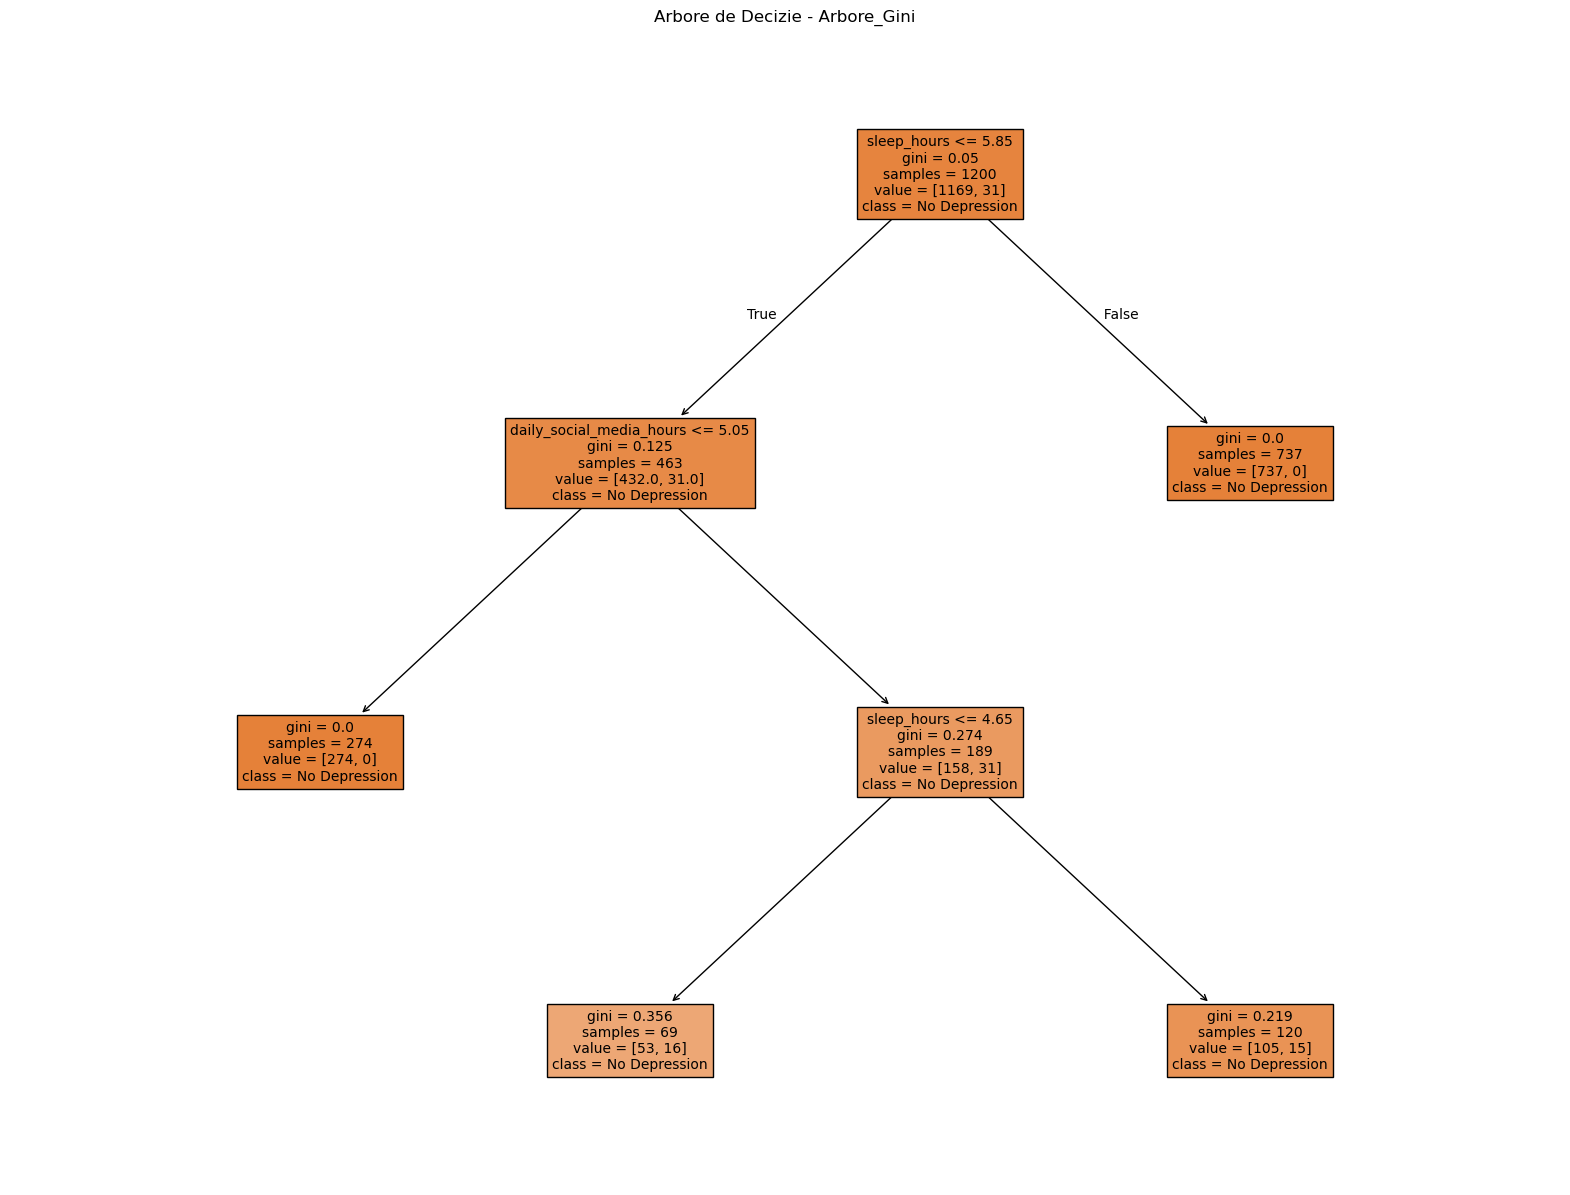

In [2]:
# experiment 1
experiment_arbore(k_fold_val=5, criteriu='gini', adancime=3, min_leaf=5, nume_exp="Arbore_Gini")



--- Arbore_Entropy (Criterion=entropy, MaxDepth=5, MinLeaf=5) ---
Accuracy: 0.9691666666666666
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1169
           1       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1163    6]
 [  31    0]]

Structura arborelui (Reguli):
|--- sleep_hours <= 5.85
|   |--- daily_social_media_hours <= 5.05
|   |   |--- class: 0
|   |--- daily_social_media_hours >  5.05
|   |   |--- academic_performance <= 3.79
|   |   |   |--- daily_social_media_hours <= 7.15
|   |   |   |   |--- age <= 13.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  13.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- daily_social_media_hours >  7.15
|   |   |   |   |--- academic_performance <= 2.32
|   |   |   |   |   |--- class: 1
| 

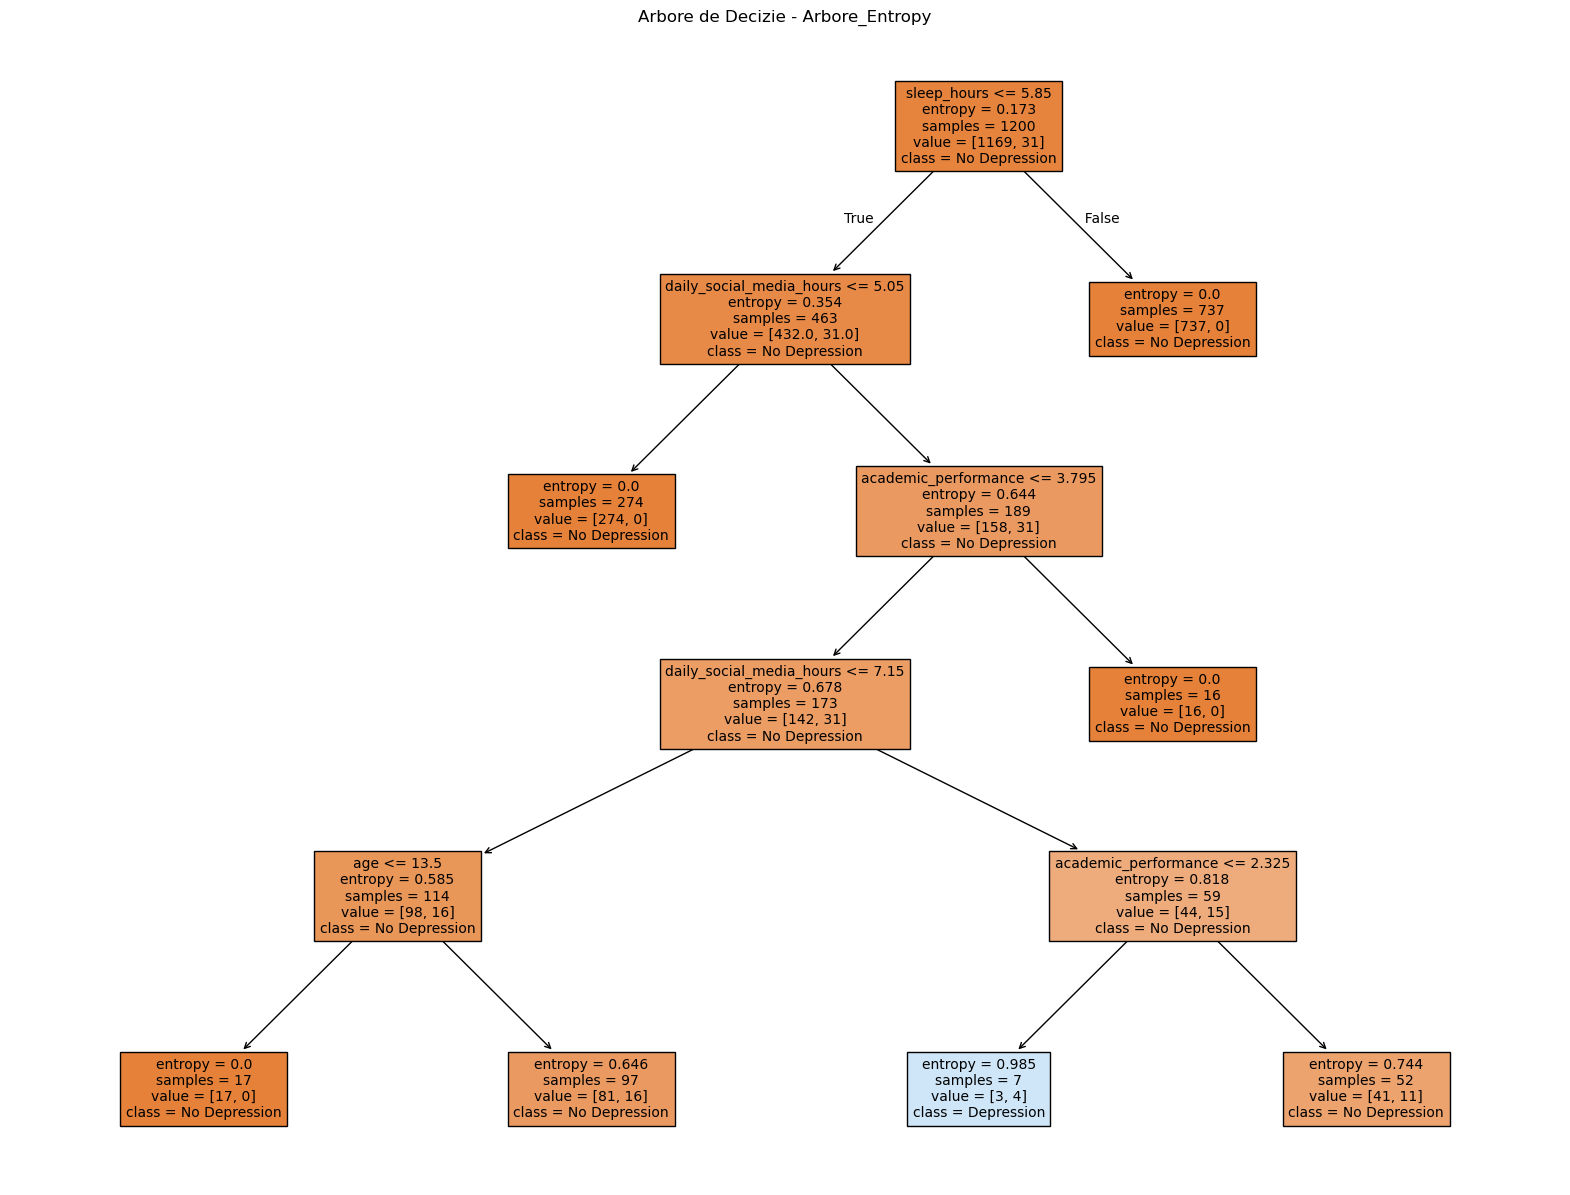

In [3]:
# experiment 2
experiment_arbore(k_fold_val=5, criteriu='entropy', adancime=5, min_leaf=5, nume_exp="Arbore_Entropy")



--- Arbore_Complex (Criterion=gini, MaxDepth=None, MinLeaf=2) ---
Accuracy: 0.9608333333333333
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1169
           1       0.21      0.19      0.20        31

    accuracy                           0.96      1200
   macro avg       0.60      0.59      0.59      1200
weighted avg       0.96      0.96      0.96      1200

Matricea de confuzie:
 [[1147   22]
 [  25    6]]

Structura arborelui (Reguli):
|--- sleep_hours <= 5.85
|   |--- daily_social_media_hours <= 5.05
|   |   |--- class: 0
|   |--- daily_social_media_hours >  5.05
|   |   |--- screen_time_before_sleep <= 0.55
|   |   |   |--- class: 1
|   |   |--- screen_time_before_sleep >  0.55
|   |   |   |--- sleep_hours <= 4.65
|   |   |   |   |--- age <= 18.50
|   |   |   |   |   |--- screen_time_before_sleep <= 2.75
|   |   |   |   |   |   |--- physical_activity <= 1.05
|   |   |   |   |   |   |   |--- daily_social_media_hours <= 6

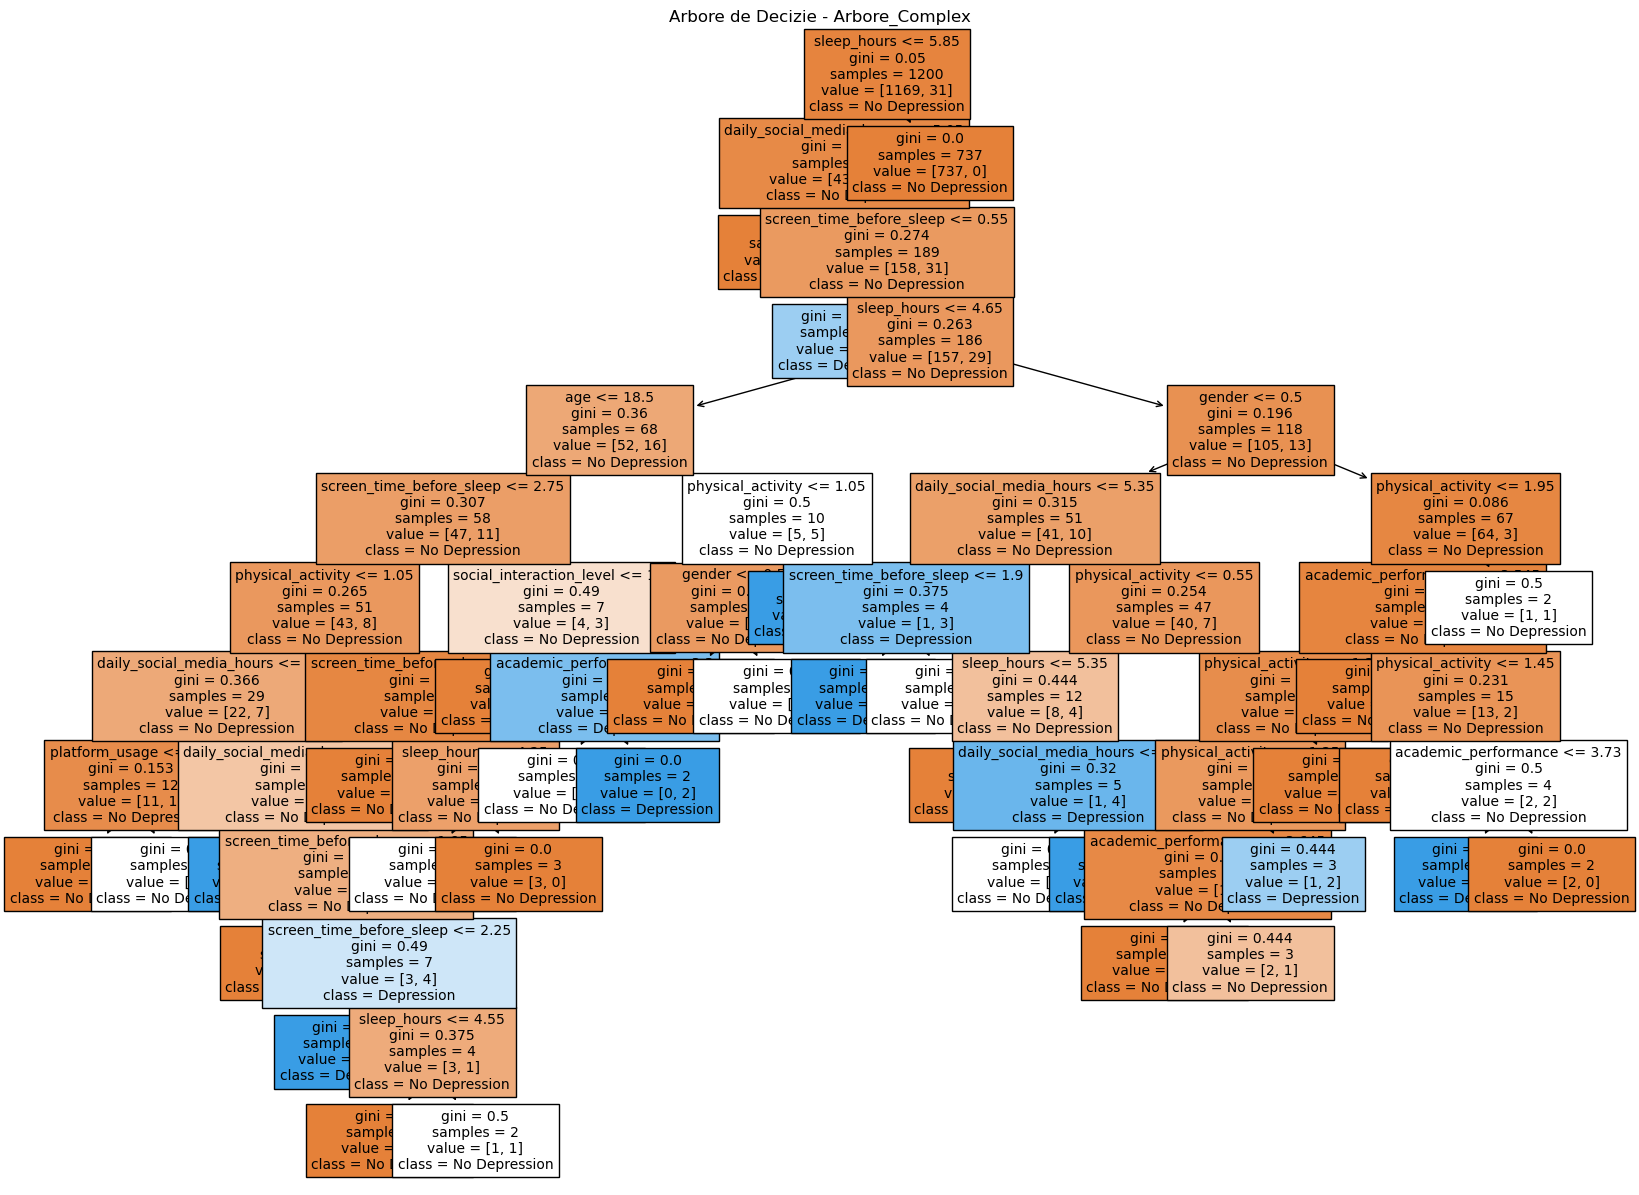

In [4]:
# experiment 3
experiment_arbore(k_fold_val=5, criteriu='gini', adancime=None, min_leaf=2, nume_exp="Arbore_Complex")



--- Arbore_Robust (Criterion=gini, MaxDepth=4, MinLeaf=20) ---
Accuracy: 0.9741666666666666
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1169
           1       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]

Structura arborelui (Reguli):
|--- sleep_hours <= 5.85
|   |--- daily_social_media_hours <= 5.05
|   |   |--- class: 0
|   |--- daily_social_media_hours >  5.05
|   |   |--- sleep_hours <= 4.65
|   |   |   |--- age <= 16.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  16.50
|   |   |   |   |--- class: 0
|   |   |--- sleep_hours >  4.65
|   |   |   |--- gender <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- gender >  0.50
|   |   |   |   |--- class: 0
|--- sleep_hours >  5.85
|   |--- class: 0



C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


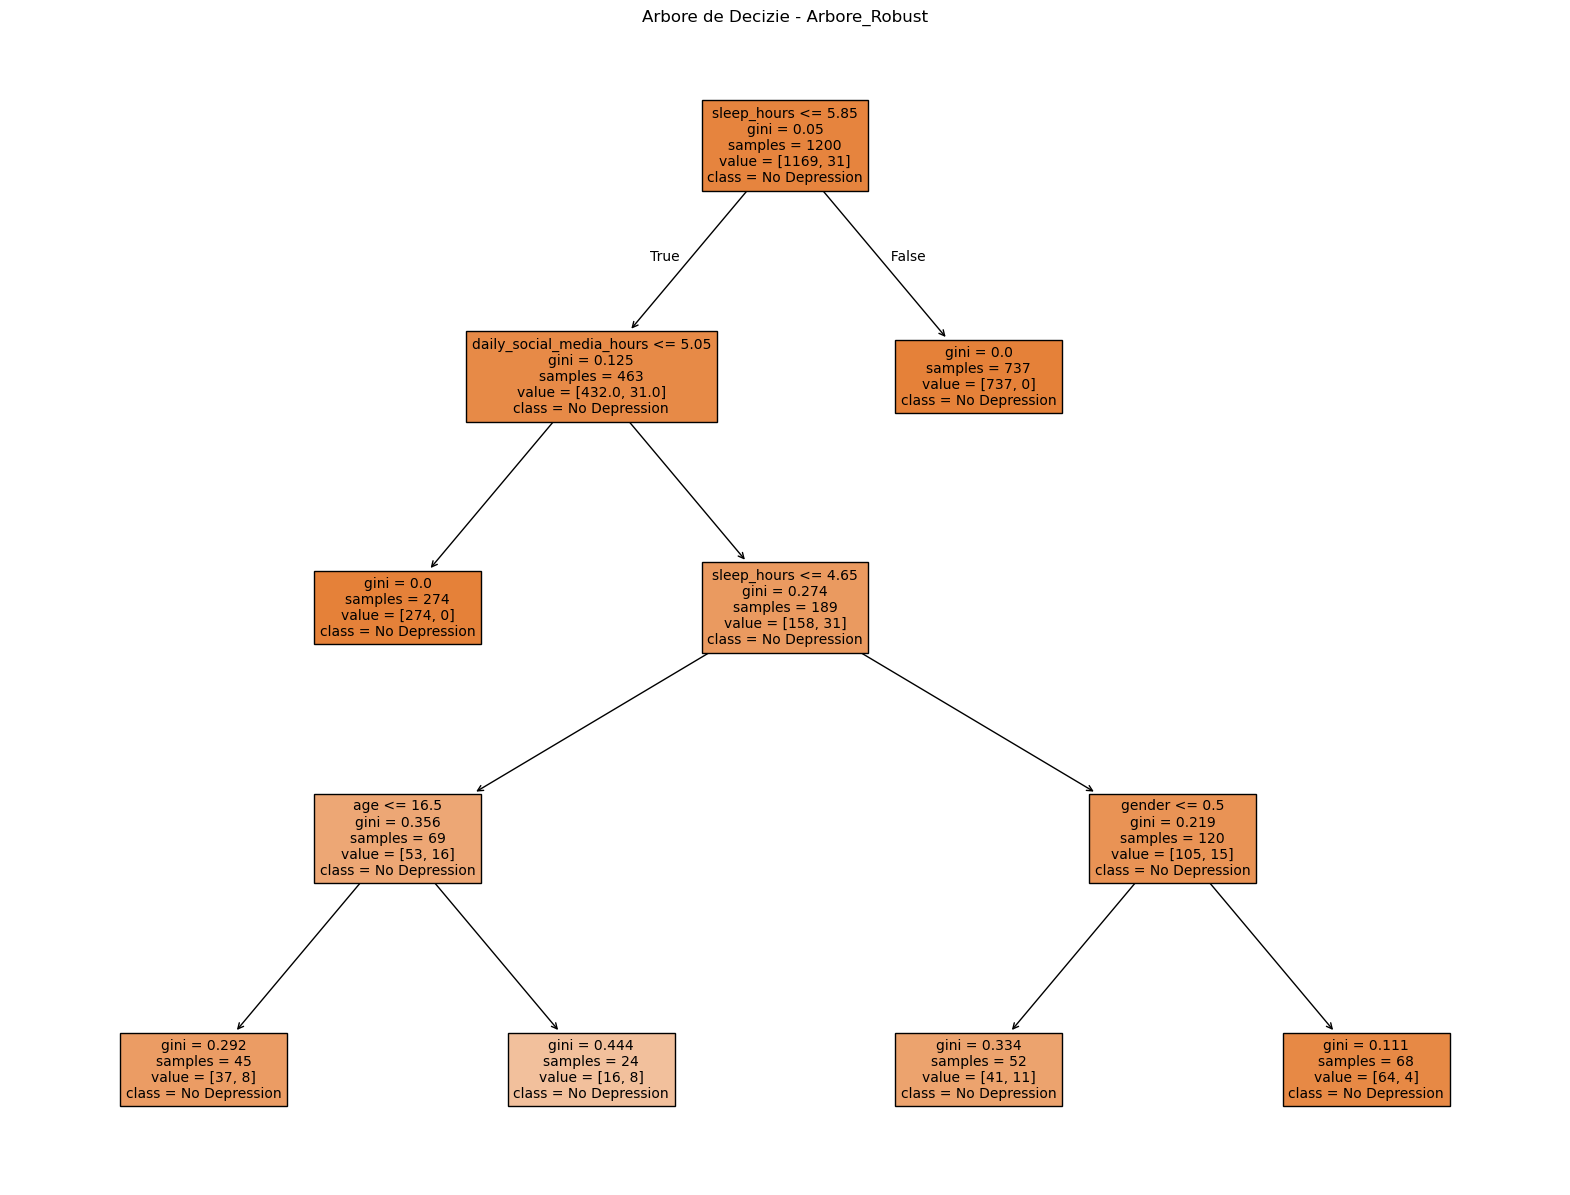

In [5]:
# experiment 4
experiment_arbore(k_fold_val=5, criteriu='gini', adancime=4, min_leaf=20, nume_exp="Arbore_Robust")